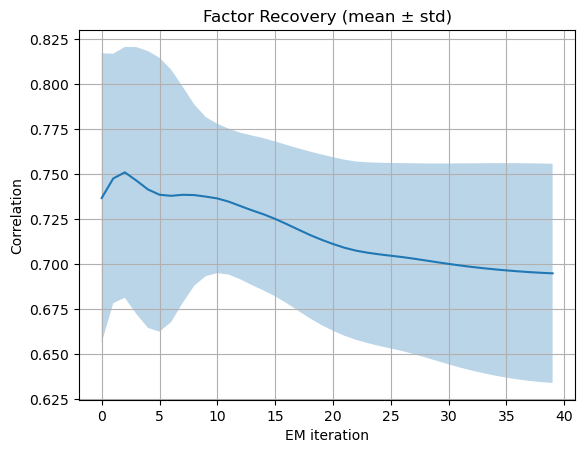

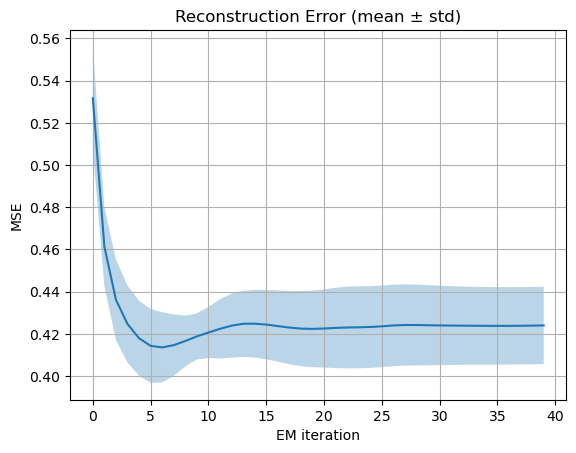

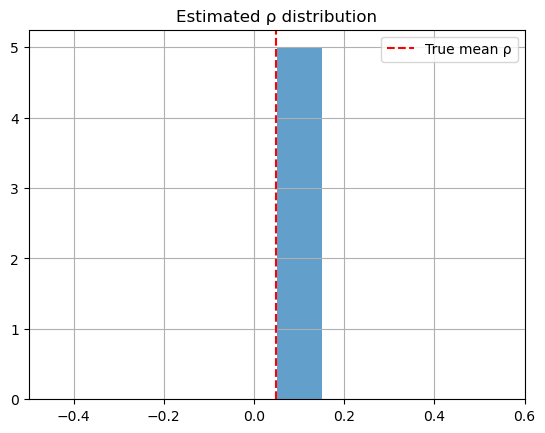

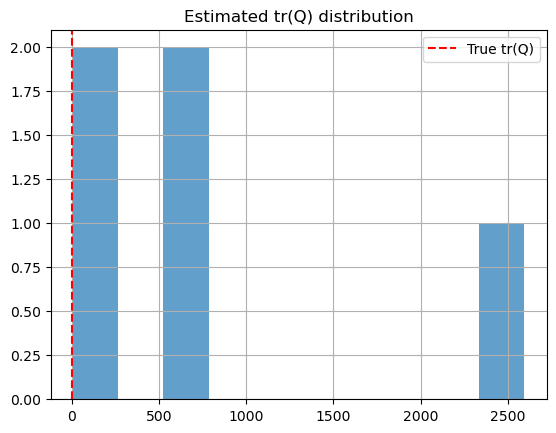

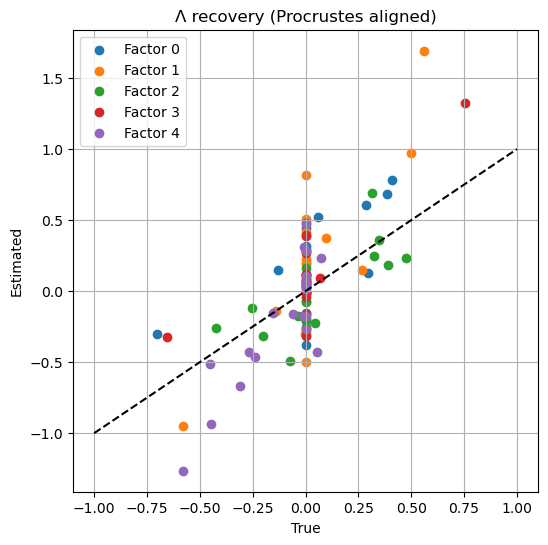

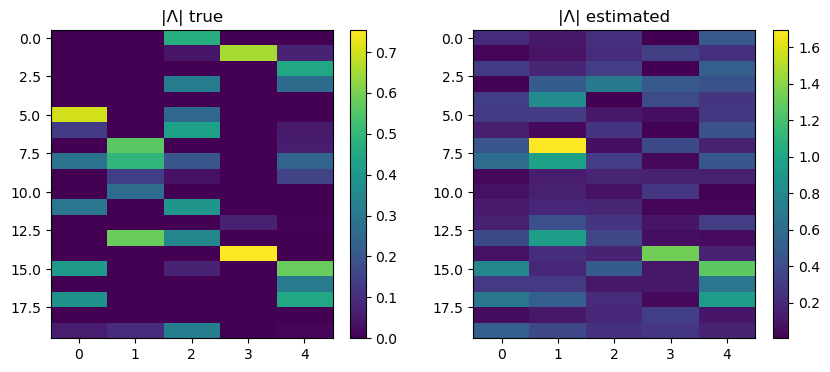

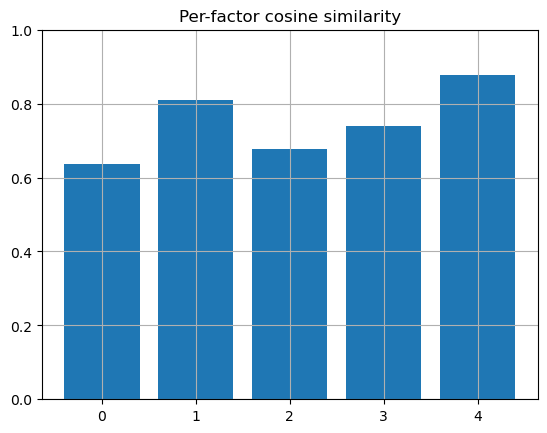

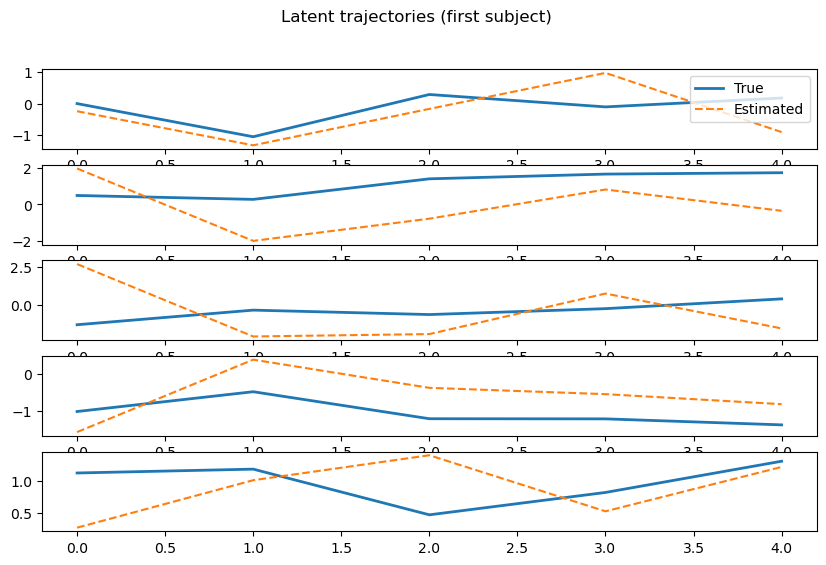

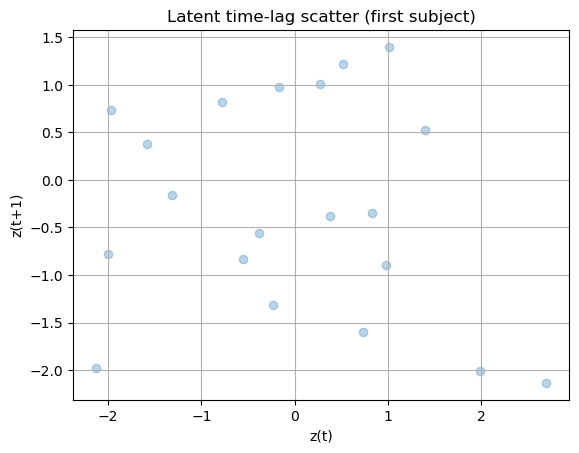

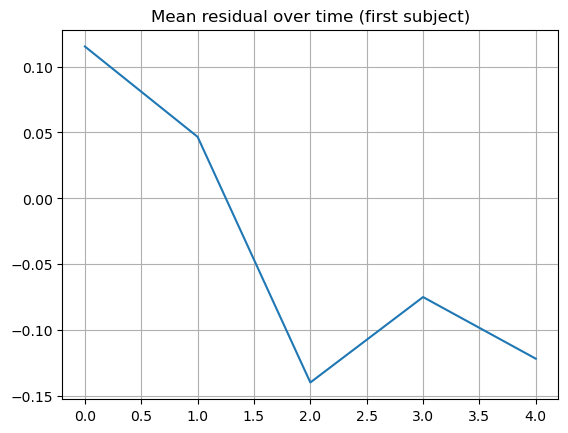

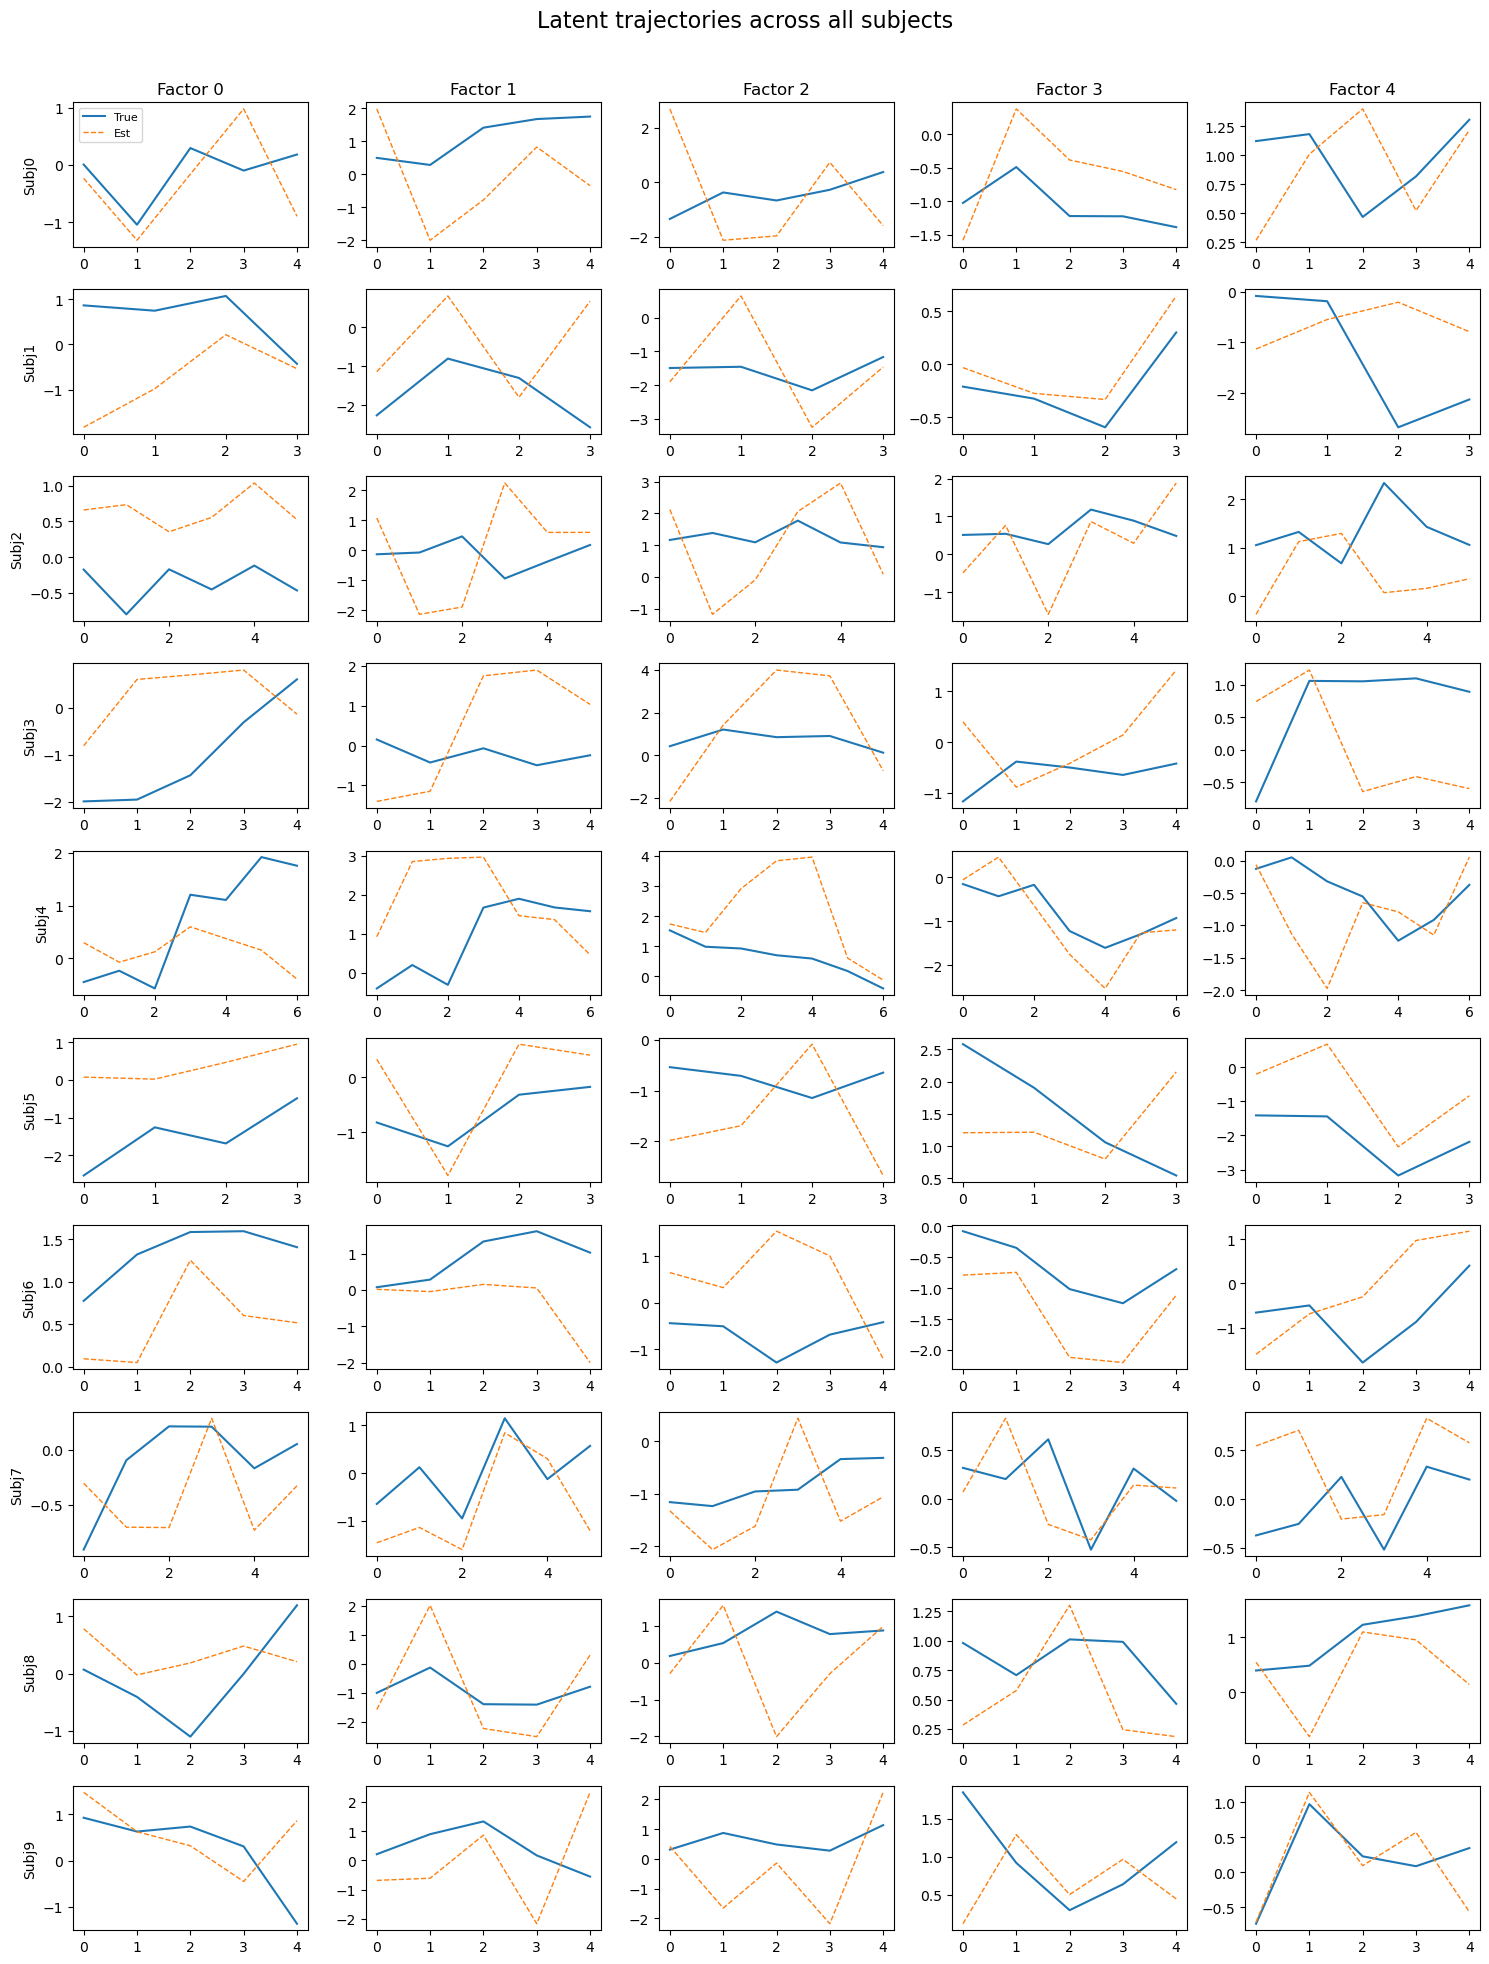

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ============================================================
# 1. DATA GENERATION
# ============================================================

def simulate_ou_dfa(seed,
                    n_subjects=10,
                    T_list=(5,4,6,5,7,4,5,6,5,5),
                    p=20,
                    k=5,
                    rho_mean=0.05,
                    rho_sd=0.03,
                    Q_scale=0.3,
                    Psi_scale=0.5,
                    sparsity=0.7):
    rng = np.random.default_rng(seed)

    # Factor loadings
    Lambda = rng.normal(size=(p, k))
    Lambda *= rng.uniform(size=(p, k)) > sparsity
    Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)

    # OU parameters (global)
    rho_true = np.abs(rng.normal(rho_mean, rho_sd))
    R = rng.normal(size=(k, k))
    Q_true = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 10.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(size=k)

        for t in range(1, T):
            A = np.exp(-rho_true * dt[t-1]) * np.eye(k)
            z[t] = A @ z[t-1] + rng.multivariate_normal(np.zeros(k), Q_true)

        Psi_diag = Psi_scale * rng.lognormal(0, 0.5, size=p)
        y = z @ Lambda.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda, rho_true, Q_true, dts_all

# ============================================================
# 2. KALMAN SMOOTHER
# ============================================================

def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]
    m, P = np.zeros(k), np.eye(k)
    m_f, P_f = [], []

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            m = A @ m
            P = A @ P @ A.T + Q

        S = Lambda @ P @ Lambda.T + Psi + 1e-6*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        m_f.append(m)
        P_f.append(P)

    Ez, Ezz, Ezztm1 = [None]*T, [None]*T, [None]*(T-1)
    Ez[-1] = m_f[-1]
    Ezz[-1] = P_f[-1] + np.outer(Ez[-1], Ez[-1])

    for t in reversed(range(T-1)):
        A = np.exp(-rho * dt[t]) * np.eye(k)
        P_pred = A @ P_f[t] @ A.T + Q
        J = P_f[t] @ A.T @ np.linalg.inv(P_pred)

        Ez[t] = m_f[t] + J @ (Ez[t+1] - A @ m_f[t])
        P = P_f[t] + J @ (Ezz[t+1] - P_pred) @ J.T

        Ezz[t] = P + np.outer(Ez[t], Ez[t])
        Ezztm1[t] = J @ Ezz[t+1]

    return Ez, Ezz, Ezztm1

# ============================================================
# 3. EM STEP
# ============================================================

def run_em(Ys, dts_all, k, seed, n_iter=40):
    rng = np.random.default_rng(seed)
    p = Ys[0].shape[1]

    Lambda = rng.normal(size=(p, k))
    Psi = np.eye(p)
    rho = 0.05  # global decay
    Q = np.eye(k)

    hist_L, hist_mse = [], []

    for _ in range(n_iter):
        Ezs, Ezzs, Ezztm1s = [], [], []

        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz, Ezztm1 = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
            Ezztm1s.append(Ezztm1)

        # ---------------- Lambda update ----------------
        Ezz_sum = sum(Ezz[t] for Ezz in Ezzs for t in range(len(Ezz)))
        Ezy_sum = sum(np.outer(Ezs[s][t], Ys[s][t])
                      for s in range(len(Ys)) for t in range(len(Ys[s])))
        Lambda = np.linalg.solve(Ezz_sum + 1e-6*np.eye(k), Ezy_sum).T

        # ---------------- Psi update ----------------
        Psi = np.diag(np.mean([
            (Ys[s][t] - Lambda @ Ezs[s][t])**2
            for s in range(len(Ys)) for t in range(len(Ys[s]))
        ], axis=0))

        # ---------------- Q update (global scale) ----------------
        Q = np.mean([
            Ezz[t+1] - np.exp(-rho*dts_all[s][t]) * Ezztm1[t].T
            for s,(Ezz,Ezztm1) in enumerate(zip(Ezzs,Ezztm1s))
            for t in range(len(Ezztm1))
        ], axis=0)

        # reconstruction error
        mse = np.mean([
            np.mean((Ys[s] - np.array(Ezs[s]) @ Lambda.T)**2)
            for s in range(len(Ys))
        ])

        hist_L.append(Lambda.copy())
        hist_mse.append(mse)

    return Lambda, rho, Q, hist_L, hist_mse, Ezs

# ============================================================
# 4. MULTI-RUN EXPERIMENT
# ============================================================

def multi_run_experiment(n_runs=5):
    rec_curves, mse_curves = [], []
    rhos, traces_Q = [], []

    for seed in range(n_runs):
        Ys, Zs, L_true, rho_true, Q_true, dts = simulate_ou_dfa(seed)
        Lambda_est, rho_est, Q_est, hist_L, hist_mse, Ezs = run_em(Ys, dts, k=L_true.shape[1], seed=seed)

        # factor recovery
        rec = []
        for Lh in hist_L:
            R,_ = orthogonal_procrustes(Lh, L_true)
            rec.append(np.corrcoef(L_true.ravel(), (Lh@R).ravel())[0,1])

        rec_curves.append(rec)
        mse_curves.append(hist_mse)
        rhos.append(rho_est)
        traces_Q.append(np.trace(Q_est))

    return np.array(rec_curves), np.array(mse_curves), rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys

# ============================================================
# 5. LATENT TRAJECTORIES OVERLAY
# ============================================================

def plot_latent_all_subjects_overlay(Z_true, Z_est):
    n_subjects = len(Z_true)
    k = Z_true[0].shape[1]

    plt.figure(figsize=(15, 4*k))
    for f in range(k):
        plt.subplot(k,1,f+1)
        for s in range(n_subjects):
            Zt = np.array(Z_true[s])
            Ze = np.array(Z_est[s])
            plt.plot(Zt[:,f], color='C0', alpha=0.3)  # true trajectories
            plt.plot(Ze[:,f], '--', color='C1', alpha=0.3)  # estimated trajectories
        plt.title(f"Factor {f}: True (solid) vs Estimated (dashed)")
        plt.xlabel("Time step")
        plt.ylabel("Latent value")
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# 6. VISUALIZATION
# ============================================================

def visualize_all(rec_curves, mse_curves, rhos, traces_Q, Lambda_true, Lambda_est, rho_true, Q_true, Z_true, Z_est, Y_true, Y_hat):
    n_runs, n_iter = rec_curves.shape
    x = np.arange(n_iter)

    # ----------------- 1. Global convergence -----------------
    plt.figure()
    plt.plot(x, rec_curves.mean(0))
    plt.fill_between(x, rec_curves.mean(0)-rec_curves.std(0), rec_curves.mean(0)+rec_curves.std(0), alpha=0.3)
    plt.title("Factor Recovery (mean ± std)")
    plt.xlabel("EM iteration")
    plt.ylabel("Correlation")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(x, mse_curves.mean(0))
    plt.fill_between(x, mse_curves.mean(0)-mse_curves.std(0), mse_curves.mean(0)+mse_curves.std(0), alpha=0.3)
    plt.title("Reconstruction Error (mean ± std)")
    plt.xlabel("EM iteration")
    plt.ylabel("MSE")
    plt.grid()
    plt.show()

    # ----------------- 2. Parameter identifiability -----------------
    plt.figure()
    plt.hist(rhos, bins=10, alpha=0.7)
    plt.axvline(rho_true.mean(), color='r', linestyle='--', label="True mean ρ")
    plt.title("Estimated ρ distribution")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure()
    plt.hist(traces_Q, bins=10, alpha=0.7)
    plt.axvline(np.trace(Q_true), color='r', linestyle='--', label="True tr(Q)")
    plt.title("Estimated tr(Q) distribution")
    plt.legend()
    plt.grid()
    plt.show()

    # ----------------- 3. Factor loadings -----------------
    R,_ = orthogonal_procrustes(Lambda_est, Lambda_true)
    L_align = Lambda_est @ R

    plt.figure(figsize=(6,6))
    for kf in range(Lambda_true.shape[1]):
        plt.scatter(Lambda_true[:,kf], L_align[:,kf], label=f"Factor {kf}")
    plt.plot([-1,1],[-1,1],'k--')
    plt.legend()
    plt.title("Λ recovery (Procrustes aligned)")
    plt.xlabel("True")
    plt.ylabel("Estimated")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(np.abs(Lambda_true), aspect='auto')
    plt.title("|Λ| true")
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.abs(L_align), aspect='auto')
    plt.title("|Λ| estimated")
    plt.colorbar()
    plt.show()

    cos_sim = np.sum(Lambda_true*L_align,axis=0)/(np.linalg.norm(Lambda_true,axis=0)*np.linalg.norm(L_align,axis=0))
    plt.figure()
    plt.bar(range(len(cos_sim)), cos_sim)
    plt.title("Per-factor cosine similarity")
    plt.ylim(0,1)
    plt.grid()
    plt.show()

    # ----------------- 4. Latent trajectories (first subject) -----------------
    Z_true_arr = np.array(Z_true[0])
    Z_est_arr = np.array(Z_est[0])
    Y_true_arr = np.array(Y_true[0])
    Y_hat_arr = np.array(Y_hat[0])
    T, k = Z_true_arr.shape

    plt.figure(figsize=(10,6))
    for i in range(k):
        plt.subplot(k,1,i+1)
        plt.plot(Z_true_arr[:,i], label="True", linewidth=2)
        plt.plot(Z_est_arr[:,i], '--', label="Estimated")
        if i==0:
            plt.legend()
    plt.suptitle("Latent trajectories (first subject)")
    plt.show()

    plt.figure()
    plt.scatter(Z_est_arr[:-1].ravel(), Z_est_arr[1:].ravel(), alpha=0.3)
    plt.title("Latent time-lag scatter (first subject)")
    plt.xlabel("z(t)")
    plt.ylabel("z(t+1)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot((Y_true_arr-Y_hat_arr).mean(1))
    plt.title("Mean residual over time (first subject)")
    plt.grid()
    plt.show()

    # ----------------- 5. Latent trajectories (all subjects grid) -----------------
    n_subjects = len(Z_true)
    k = Z_true_arr.shape[1]
    plt.figure(figsize=(15, n_subjects*2))
    for s in range(n_subjects):
        Zt = np.array(Z_true[s])
        Ze = np.array(Z_est[s])
        T = Zt.shape[0]
        for f in range(k):
            plt.subplot(n_subjects, k, s*k + f + 1)
            plt.plot(range(T), Zt[:,f], label="True", linewidth=1.5)
            plt.plot(range(T), Ze[:,f], '--', label="Est", linewidth=1)
            if s==0 and f==0:
                plt.legend(fontsize=8)
            if f==0:
                plt.ylabel(f"Subj{s}")
            if s==0:
                plt.title(f"Factor {f}")
    plt.suptitle("Latent trajectories across all subjects", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

# ============================================================
# 7. MAIN
# ============================================================

if __name__=="__main__":
    rec_curves, mse_curves, rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys = multi_run_experiment(n_runs=5)
    Y_hat = [np.array(Ez) @ Lambda_est.T for Ez in Ezs]

    visualize_all(rec_curves, mse_curves, rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys, Y_hat)
